이상치 제거 및 섭씨를 화씨로 변환

In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
from scipy.stats import boxcox
from scipy.special import inv_boxcox
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    mean_absolute_error,
    median_absolute_error,
    mean_absolute_percentage_error
)

# ──────────────────────────────────────────────────
# 1) 데이터 로드 & IQR 기반 이상치 제거
# ──────────────────────────────────────────────────
df = pd.read_csv("Final_cleaned_data.csv")

# 이상치 제거 대상 리스트
continuous_cols = [
    'travelDurationMinutes',
    'start_humidity',
    'start_windgust',
    'start_windspeed',
    'destin_humidity',
    'destin_windgust',
    'destin_windspeed',
]

# (1) 섭씨 → 화씨 변환 (출발지)
df['start_temp']      = df['start_temp'] * 9/5 + 32
df['start_feelslike'] = df['start_feelslike'] * 9/5 + 32

# (1.1) 섭씨 → 화씨 변환 (도착지)
df['destin_temp']      = df['destin_temp'] * 9/5 + 32
df['destin_feelslike'] = df['destin_feelslike'] * 9/5 + 32

# (2) IQR 계산
Q1  = df[continuous_cols].quantile(0.25)
Q3  = df[continuous_cols].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# (3) 이상치 마스크 생성 및 제거
mask = ~((df[continuous_cols] < lower_bound) | (df[continuous_cols] > upper_bound)).any(axis=1)
df_cleaned = df[mask].copy()

print(f"제거 전 샘플 수: {len(df)}")
print(f"제거 후 샘플 수: {len(df_cleaned)}")
print(f"제거된 샘플 수: {len(df) - len(df_cleaned)}")

# ──────────────────────────────────────────────────
# 2) Box-Cox 변환 (baseFare > 0 필터링 및 λ 저장)
# ──────────────────────────────────────────────────
df_boxcox = df_cleaned[df_cleaned['baseFare'] > 0].copy()

# Box-Cox 변환 적용 및 학습 때 쓸 λ 저장
df_boxcox['boxcox_baseFare'], fitted_lambda = boxcox(df_boxcox['baseFare'])

# (선택) λ를 추후에 재사용할 경우 pickle 등에 저장해 두려면:
import pickle
with open('fitted_lambda.pkl', 'wb') as f:
  pickle.dump(fitted_lambda, f)

# ──────────────────────────────────────────────────
# 3) 피처 정리 (불필요 컬럼 제거)
# ──────────────────────────────────────────────────
drop_cols = [
    'baseFare',
    'boxcox_baseFare',
    'log_baseFare',
    'fare_per_minute',
    'via_count',
    'daysBeforeFlight'
]
existing = [col for col in drop_cols if col in df_boxcox.columns]
X = df_boxcox.drop(columns=existing)            # 모델 입력용 피처
y = df_boxcox['boxcox_baseFare'].values         # Box-Cox 스케일 타깃

print("제거 전 X shape:", df_boxcox.shape)
print("제거 후 X shape:", X.shape)
print("X.columns에 제거 대상 있는지 확인:", set(drop_cols) & set(X.columns))  # 빈 집합이어야 함

# ──────────────────────────────────────────────────
# 4) train / valid / test 분리 (7:1:2)
# ──────────────────────────────────────────────────
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_temp, y_temp, test_size=0.125, random_state=42
)

print(f"\n############ 데이터 분할 결과 ############")
print(f"Train: {X_train.shape}, Valid: {X_valid.shape}, Test: {X_test.shape}")

# ──────────────────────────────────────────────────
# 5) 피처 스케일링 (StandardScaler)
# ──────────────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled  = scaler.transform(X_test)



제거 전 샘플 수: 821388
제거 후 샘플 수: 769423
제거된 샘플 수: 51965
제거 전 X shape: (769423, 41)
제거 후 X shape: (769423, 39)
X.columns에 제거 대상 있는지 확인: set()

############ 데이터 분할 결과 ############
Train: (538595, 39), Valid: (76943, 39), Test: (153885, 39)


Random Search로 최적의 파라미터 찾기

In [56]:

# ──────────────────────────────────────────────────
#랜덤 서치로 최적의 파라미터 잡기
# ──────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score, make_scorer
from scipy.special import inv_boxcox
from lightgbm import LGBMRegressor
from scipy.stats import randint, uniform
import numpy as np



# RandomizedSearchCV 설정 (LightGBM 용)
base_model = LGBMRegressor(
    objective="regression",
    metric="rmse",
    n_jobs=-1,
    random_state=42
)

param_dist = {
    # n_estimators
    "n_estimators":    [500, 1000, 2000, 3000],
    # learning_rate
    "learning_rate":   [0.03, 0.05, 0.1, 0.2],
    # max_depth
    "max_depth":       [6, 8, 10],
    #reg_lambda
    "reg_lambda":      [1, 3, 5, 7],
    # subsample만 두고 부트스트랩 방식을 LightGBM 기본(bagging_fraction)으로 둠
    "subsample":       [0.6, 0.8, 1.0],
    # colsample_bytree: feature_fraction
    "colsample_bytree": [0.6, 0.8, 1.0]
}

# 평가 지표(RMSE)
rmse_scorer = make_scorer(
    lambda y_true, y_pred: mean_squared_error(y_true, y_pred, squared=False),
    greater_is_better=False
)

random_search = RandomizedSearchCV(
    estimator           = base_model,
    param_distributions = param_dist,
    n_iter              = 5,
    scoring             = rmse_scorer,
    cv                  = 3,
    random_state        = 42,
    n_jobs              = -1,
    verbose             = 3
)

# RandomizedSearchCV 실행
random_search.fit(X_train, y_train)

# 최적 모델 추출 및 성능 평가
best_model = random_search.best_estimator_

print("\n 최적 하이퍼파라미터:", random_search.best_params_)

# 최적의 하이퍼파라미터를 구하는데 시간이 많이 걸립니다. 그런데 실수로 다시 코드를 실행하는 버튼을 누르는 바람에 결과가 다 날아갔습니다.
# 최적의 하이퍼파라미터는 아래에 모두 반영이 되어 있습니다.

Fitting 3 folds for each of 5 candidates, totalling 15 fits


KeyboardInterrupt: 

최적의 하이퍼파라미터를 반영한 모델 생성

In [91]:
# ──────────────────────────────────────────────────
# 6) LightGBM 모델 학습 (주어진 최적 하이퍼파라미터)
# ──────────────────────────────────────────────────
params = {
    "n_estimators":     1000,
    "learning_rate":    0.2,
    "max_depth":        10,
    "subsample":        0.8,
    "colsample_bytree": 0.8,
    "reg_lambda":       7,
    "objective":        "regression",
    "metric":           "rmse",
    "random_state":     42,
    "n_jobs":           -1,
}

model = lgb.LGBMRegressor(**params)

# 조기 종료(early stopping) 콜백 정의
early_stop = lgb.early_stopping(stopping_rounds=100, verbose=True)
log_eval   = lgb.log_evaluation(period=50)

model.fit(
    X_train_scaled, y_train,
    eval_set=[(X_valid_scaled, y_valid)],
    eval_metric="rmse",
    callbacks=[early_stop, log_eval]
)


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.183301 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4357
[LightGBM] [Info] Number of data points in the train set: 538595, number of used features: 39
[LightGBM] [Info] Start training from score 20.213420
Training until validation scores don't improve for 100 rounds
[50]	valid_0's rmse: 3.1807
[100]	valid_0's rmse: 3.07309
[150]	valid_0's rmse: 3.0037
[200]	valid_0's rmse: 2.94919
[250]	valid_0's rmse: 2.91736
[300]	valid_0's rmse: 2.87584
[350]	valid_0's rmse: 2.849
[400]	valid_0's rmse: 2.82541
[450]	valid_0's rmse: 2.80266
[500]	valid_0's rmse: 2.78471
[550]	valid_0's rmse: 2.77209
[600]	valid_0's rmse: 2.757
[650]	valid_0's rmse: 2.74757
[700]	valid_0's rmse: 2.73497
[750]	valid_0's rmse: 2.72549
[800]	valid_0's rmse: 2.71677
[850]	valid_0's rmse: 2.70894
[900]	valid_0's rmse: 2.700

LGBMRegressor(colsample_bytree=0.8, learning_rate=0.2, max_depth=10,
              metric='rmse', n_estimators=1000, n_jobs=-1,
              objective='regression', random_state=42, reg_lambda=7,
              subsample=0.8)

In [92]:
# ──────────────────────────────────────────────────
# 7) Validation 세트 성능 확인 (Box-Cox 스케일)
# ──────────────────────────────────────────────────
y_valid_pred = model.predict(X_valid_scaled)
mse_valid    = mean_squared_error(y_valid, y_valid_pred)
r2_valid     = r2_score(y_valid, y_valid_pred)

print(f"\n--Validation Set 성능 (Box-Cox 스케일)────────────────────────")
print(f"MSE: {mse_valid:.4f}")
print(f"R² Score: {r2_valid:.4f}")
# ──────────────────────────────────────────────────
# 8) Test 세트 예측 및 평가 (Box-Cox 스케일)
# ──────────────────────────────────────────────────
best_iter       = model.best_iteration_
y_test_pred_box = model.predict(X_test_scaled, num_iteration=best_iter)

mse_test    = mean_squared_error(y_test, y_test_pred_box)
rmse_test   = np.sqrt(mse_test)
r2_test     = r2_score(y_test, y_test_pred_box)
mape_test   = mean_absolute_percentage_error(y_test, y_test_pred_box)

print(f"\n--Test Set 성능 (Box-Cox 스케일)────────────────────────")
print(f"MSE:  {mse_test:.4f}")
print(f"RMSE: {rmse_test:.4f}")
print(f"R²:   {r2_test:.4f}")
print(f"MAPE: {mape_test * 100:.4f}%")

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



--Validation Set 성능 (Box-Cox 스케일)────────────────────────
MSE: 7.2193
R² Score: 0.7824


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



--Test Set 성능 (Box-Cox 스케일)────────────────────────
MSE:  7.3643
RMSE: 2.7137
R²:   0.7771
MAPE: 1489895253217854.7500%


In [93]:
# ──────────────────────────────────────────────────
# 9) Test 예측값 역변환 & 원래 스케일에서 평가
# ──────────────────────────────────────────────────
# (1) 역변환 (Box-Cox → 원본 baseFare 단위)
y_test_pred_orig = inv_boxcox(y_test_pred_box, fitted_lambda)

# (2) 원본 baseFare (테스트용 실제값)
#     train_test_split 시 그대로 y_test는 “Box-Cox 스케일”이므로,
#     원본값은 df_boxcox['baseFare']에서 동일 인덱스 슬라이스
#     다만 train_test_split이 인덱스를 섞었으므로, 여기서는 y_test 인덱스가 원본 인덱스이므로 다음과 같이 사용
test_indices     = X_test.index
y_test_orig      = df_boxcox.loc[test_indices, 'baseFare'].values

# (3) 원본 스케일 평가 지표
mse_orig   = mean_squared_error(y_test_orig, y_test_pred_orig)
r2_orig    = r2_score(y_test_orig, y_test_pred_orig)
mae_orig   = mean_absolute_error(y_test_orig, y_test_pred_orig)
medae_orig = median_absolute_error(y_test_orig, y_test_pred_orig)
mape_orig  = mean_absolute_percentage_error(y_test_orig, y_test_pred_orig)

print(f"\n--Test Set 성능 (원본 스케일)────────────────────────")
print(f"MSE           : {mse_orig:.2f}")
print(f"R² Score      : {r2_orig:.2f}")
print(f"MAE           : {mae_orig:.2f}")
print(f"Median AE     : {medae_orig:.2f}")
print(f"MAPE (실제 %) : {mape_orig * 100:.2f}%")


--Test Set 성능 (원본 스케일)────────────────────────
MSE           : 9216.53
R² Score      : 0.71
MAE           : 60.52
Median AE     : 41.72
MAPE (실제 %) : 36.65%


In [99]:
import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# ── (1) X, y 준비 ────────────────────────────────────────────────────────────
# X: Pandas DataFrame, y: NumPy 1D 배열 (Box-Cox 스케일된 타깃)
# 예시:
# X = df_boxcox.drop(columns=drop_cols)
# y = df_boxcox['boxcox_baseFare'].values

# ── (2) 모델 하이퍼파라미터 정의 ──────────────────────────────────────────────
params = {
    "n_estimators":      1000,
    "learning_rate":     0.2,
    "max_depth":         10,
    "subsample":         0.8,
    "colsample_bytree":  0.8,
    "reg_lambda":        7,
    "objective":         "regression",
    "random_state":      42,
    "n_jobs":            -1,
}

# ── (3) K-Fold 설정 ───────────────────────────────────────────────────────────
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# ── (4) Fold별 결과 저장 리스트 초기화 ─────────────────────────────────────────
rmse_list = []
r2_list   = []
mae_list  = []

# ── (5) 교차검증 루프 ─────────────────────────────────────────────────────────
for fold, (train_idx, valid_idx) in enumerate(kf.split(X, y), 1):
    print(f"\n>>> Fold {fold} 학습 시작")

    # (a) train/valid 분리
    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y[train_idx], y[valid_idx]

    # (b) 스케일러 fit → transform
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_valid_scaled = scaler.transform(X_valid)

    # (c) 모델 초기화
    model = LGBMRegressor(**params)

    # (d) LightGBM 콜백 정의
    #    early_stopping: 100번 연속으로 검증 RMSE가 개선되지 않으면 학습 중단
    early_stop = lgb.early_stopping(stopping_rounds=100, verbose=False)
    #    원하면 로그 출력 콜백 추가
    log_eval = lgb.log_evaluation(period=100, show_stdv=False)

    # (e) 모델 학습 (callback에 early_stop, log_eval만 전달)
    model.fit(
        X_train_scaled,
        y_train,
        eval_set=[(X_valid_scaled, y_valid)],
        eval_metric="rmse",
        callbacks=[early_stop, log_eval]
    )

    # (f) 검증 예측 및 평가
    y_pred_valid = model.predict(X_valid_scaled, num_iteration=model.best_iteration_)
    rmse = np.sqrt(mean_squared_error(y_valid, y_pred_valid))
    r2   = r2_score(y_valid, y_pred_valid)
    mae  = mean_absolute_error(y_valid, y_pred_valid)

    print(f"Fold {fold} → RMSE: {rmse:.4f}, R²: {r2:.4f}, MAE: {mae:.4f}")

    rmse_list.append(rmse)
    r2_list.append(r2)
    mae_list.append(mae)

# ── (6) 교차검증 평균 출력 ────────────────────────────────────────────────────
print("\n===== K-Fold 교차검증 결과 =====")
print(f"Average RMSE : {np.mean(rmse_list):.4f} ± {np.std(rmse_list):.4f}")
print(f"Average R²   : {np.mean(r2_list):.4f} ± {np.std(r2_list):.4f}")
print(f"Average MAE  : {np.mean(mae_list):.4f} ± {np.std(mae_list):.4f}")



>>> Fold 1 학습 시작


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.383848 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4357
[LightGBM] [Info] Number of data points in the train set: 615538, number of used features: 39
[LightGBM] [Info] Start training from score 20.208280
[100]	valid_0's rmse: 3.09624	valid_0's l2: 9.58668
[200]	valid_0's rmse: 2.97142	valid_0's l2: 8.82934
[300]	valid_0's rmse: 2.89568	valid_0's l2: 8.38496
[400]	valid_0's rmse: 2.84802	valid_0's l2: 8.11121
[500]	valid_0's rmse: 2.80983	valid_0's l2: 7.89516
[600]	valid_0's rmse: 2.77811	valid_0's l2: 7.71792
[700]	valid_0's rmse: 2.75787	valid_0's l2: 7.60586
[800]	valid_0's rmse: 2.7371	valid_0's l2: 7.49174
[900]	valid_0's rmse: 2.7181	valid_0's l2: 7.38809
[1000]	valid_0's rmse: 2.70411	valid_0's l2: 7.31222


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Fold 1 → RMSE: 2.7041, R²: 0.7787, MAE: 2.0014

>>> Fold 2 학습 시작


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.243054 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4353
[LightGBM] [Info] Number of data points in the train set: 615538, number of used features: 39
[LightGBM] [Info] Start training from score 20.211327
[100]	valid_0's rmse: 3.08909	valid_0's l2: 9.54248
[200]	valid_0's rmse: 2.96514	valid_0's l2: 8.79204
[300]	valid_0's rmse: 2.88416	valid_0's l2: 8.31839
[400]	valid_0's rmse: 2.83451	valid_0's l2: 8.03443
[500]	valid_0's rmse: 2.79045	valid_0's l2: 7.78662
[600]	valid_0's rmse: 2.75945	valid_0's l2: 7.61455
[700]	valid_0's rmse: 2.73346	valid_0's l2: 7.47179
[800]	valid_0's rmse: 2.71432	valid_0's l2: 7.36753
[900]	valid_0's rmse: 2.69682	valid_0's l2: 7.27282
[1000]	valid_0's rmse: 2.68203	valid_0's l2: 7.19328


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Fold 2 → RMSE: 2.6820, R²: 0.7856, MAE: 1.9981

>>> Fold 3 학습 시작


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.248889 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4354
[LightGBM] [Info] Number of data points in the train set: 615538, number of used features: 39
[LightGBM] [Info] Start training from score 20.207701
[100]	valid_0's rmse: 3.08204	valid_0's l2: 9.49898
[200]	valid_0's rmse: 2.95262	valid_0's l2: 8.71794
[300]	valid_0's rmse: 2.88143	valid_0's l2: 8.30261
[400]	valid_0's rmse: 2.83626	valid_0's l2: 8.0444
[500]	valid_0's rmse: 2.79551	valid_0's l2: 7.81488
[600]	valid_0's rmse: 2.76578	valid_0's l2: 7.64952
[700]	valid_0's rmse: 2.74029	valid_0's l2: 7.50919
[800]	valid_0's rmse: 2.72198	valid_0's l2: 7.40916
[900]	valid_0's rmse: 2.7027	valid_0's l2: 7.30461
[1000]	valid_0's rmse: 2.68907	valid_0's l2: 7.23109


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Fold 3 → RMSE: 2.6891, R²: 0.7837, MAE: 1.9941

>>> Fold 4 학습 시작


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.433582 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4352
[LightGBM] [Info] Number of data points in the train set: 615539, number of used features: 39
[LightGBM] [Info] Start training from score 20.207982
[100]	valid_0's rmse: 3.06876	valid_0's l2: 9.41731
[200]	valid_0's rmse: 2.94002	valid_0's l2: 8.64371
[300]	valid_0's rmse: 2.87043	valid_0's l2: 8.23936
[400]	valid_0's rmse: 2.82519	valid_0's l2: 7.98169
[500]	valid_0's rmse: 2.7872	valid_0's l2: 7.7685
[600]	valid_0's rmse: 2.75365	valid_0's l2: 7.58256
[700]	valid_0's rmse: 2.72848	valid_0's l2: 7.44463
[800]	valid_0's rmse: 2.7086	valid_0's l2: 7.33653
[900]	valid_0's rmse: 2.69043	valid_0's l2: 7.2384
[1000]	valid_0's rmse: 2.67599	valid_0's l2: 7.1609


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Fold 4 → RMSE: 2.6760, R²: 0.7841, MAE: 1.9929

>>> Fold 5 학습 시작


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.256849 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4353
[LightGBM] [Info] Number of data points in the train set: 615539, number of used features: 39
[LightGBM] [Info] Start training from score 20.208482
[100]	valid_0's rmse: 3.06595	valid_0's l2: 9.40004
[200]	valid_0's rmse: 2.94508	valid_0's l2: 8.67352
[300]	valid_0's rmse: 2.87091	valid_0's l2: 8.24212
[400]	valid_0's rmse: 2.82267	valid_0's l2: 7.96749
[500]	valid_0's rmse: 2.78374	valid_0's l2: 7.74919
[600]	valid_0's rmse: 2.7544	valid_0's l2: 7.58672
[700]	valid_0's rmse: 2.72821	valid_0's l2: 7.44312
[800]	valid_0's rmse: 2.70764	valid_0's l2: 7.3313
[900]	valid_0's rmse: 2.68885	valid_0's l2: 7.22994
[1000]	valid_0's rmse: 2.67293	valid_0's l2: 7.14456


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Fold 5 → RMSE: 2.6729, R²: 0.7847, MAE: 1.9900

===== K-Fold 교차검증 결과 =====
Average RMSE : 2.6848 ± 0.0111
Average R²   : 0.7833 ± 0.0024
Average MAE  : 1.9953 ± 0.0040


<ipython-input-94-f9e9bc961197>:14: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-94-f9e9bc961197>:14: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-94-f9e9bc961197>:14: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-94-f9e9bc961197>:14: UserWarning: Glyph 52992 (\N{HANGUL SYLLABLE KE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-94-f9e9bc961197>:14: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 

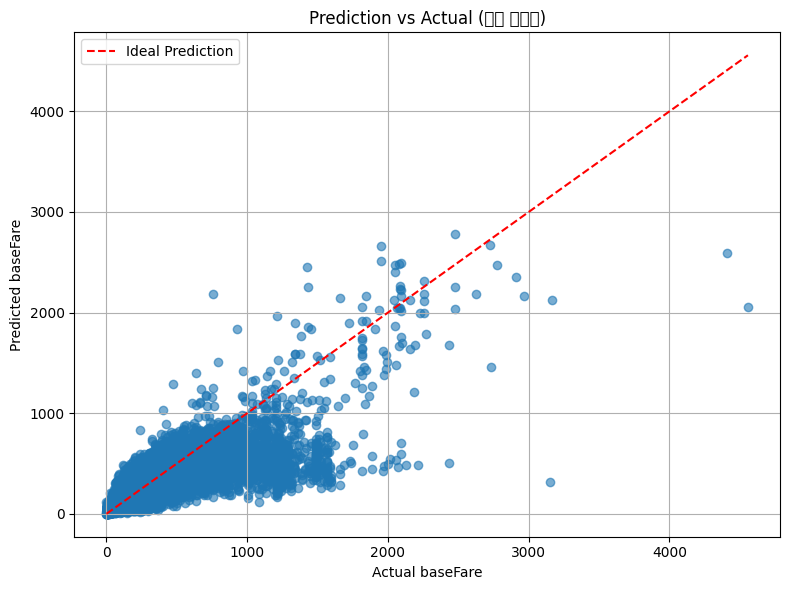

<ipython-input-94-f9e9bc961197>:25: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-94-f9e9bc961197>:25: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-94-f9e9bc961197>:25: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-94-f9e9bc961197>:25: UserWarning: Glyph 52992 (\N{HANGUL SYLLABLE KE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-94-f9e9bc961197>:25: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


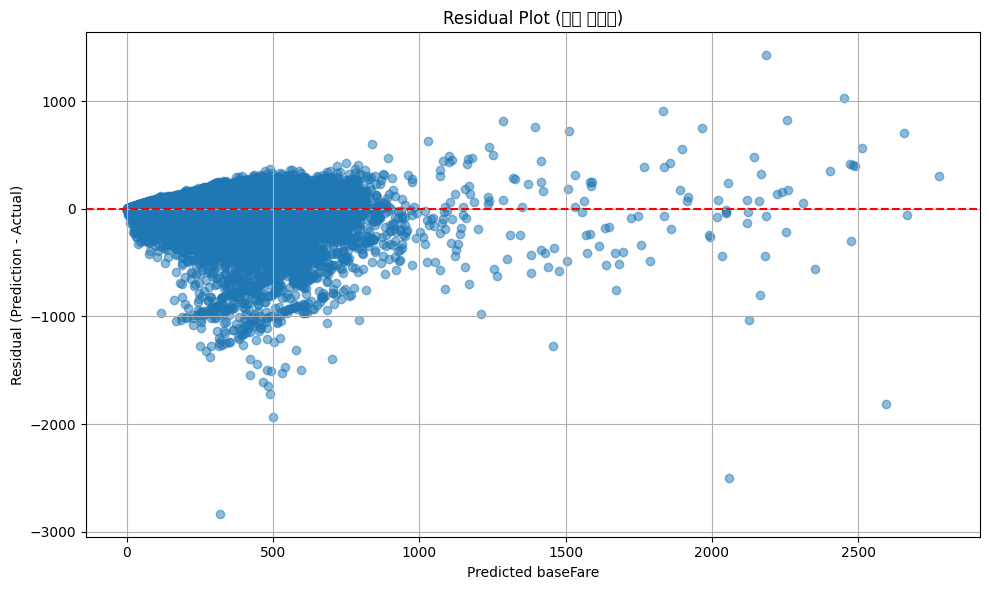

<ipython-input-94-f9e9bc961197>:34: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-94-f9e9bc961197>:34: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-94-f9e9bc961197>:34: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-94-f9e9bc961197>:34: UserWarning: Glyph 52992 (\N{HANGUL SYLLABLE KE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-94-f9e9bc961197>:34: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


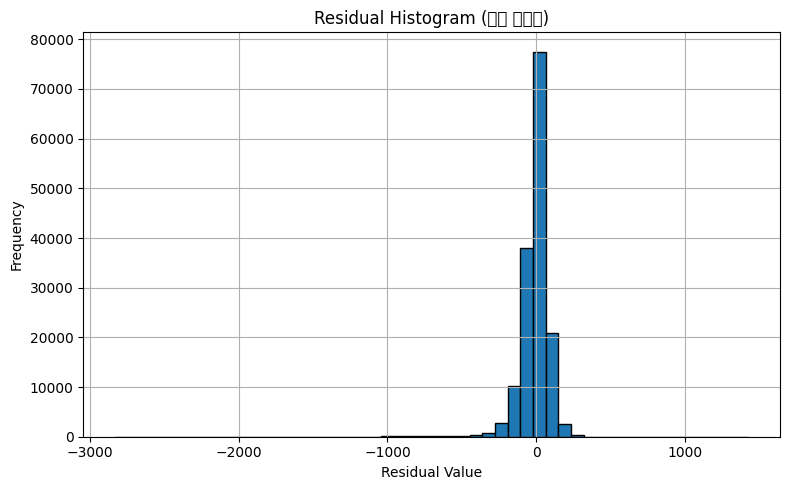

In [94]:
# ──────────────────────────────────────────────────
# 10) 예측 vs 실제값 산점도 & Residual Plot
# ──────────────────────────────────────────────────
plt.figure(figsize=(8, 6))
plt.scatter(y_test_orig, y_test_pred_orig, alpha=0.6)
plt.plot([y_test_orig.min(), y_test_orig.max()],
         [y_test_orig.min(), y_test_orig.max()],
         color='red', linestyle='--', label='Ideal Prediction')
plt.xlabel('Actual baseFare')
plt.ylabel('Predicted baseFare')
plt.title('Prediction vs Actual (원본 스케일)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

residuals = y_test_pred_orig - y_test_orig
plt.figure(figsize=(10, 6))
plt.scatter(y_test_pred_orig, residuals, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted baseFare")
plt.ylabel("Residual (Prediction - Actual)")
plt.title("Residual Plot (원본 스케일)")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=50, edgecolor='black')
plt.title("Residual Histogram (원본 스케일)")
plt.xlabel("Residual Value")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()


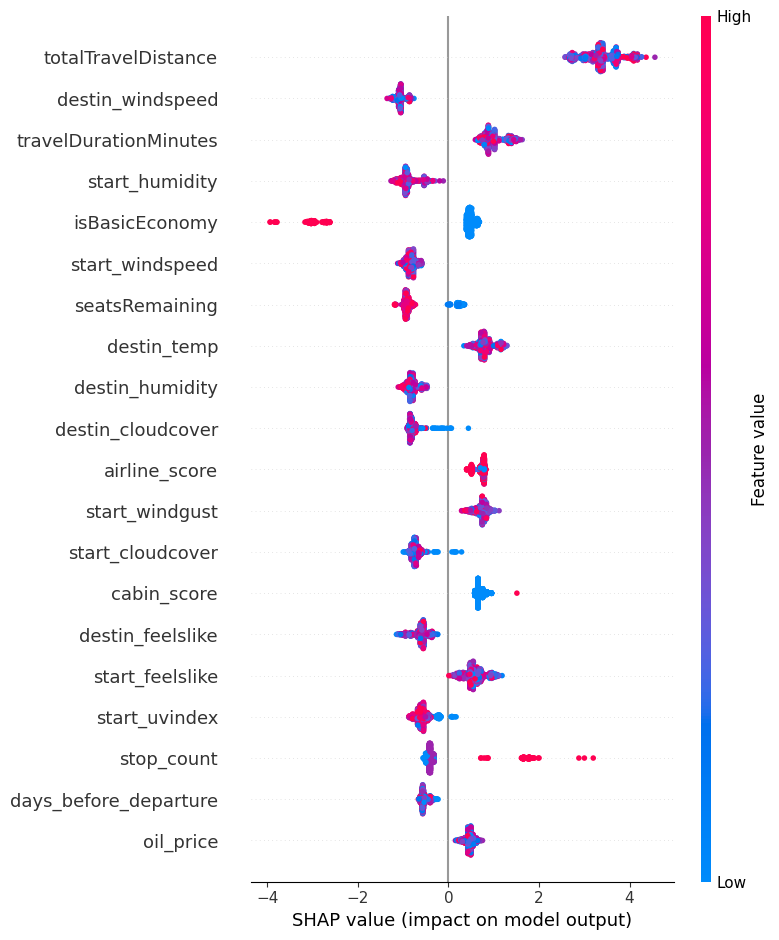

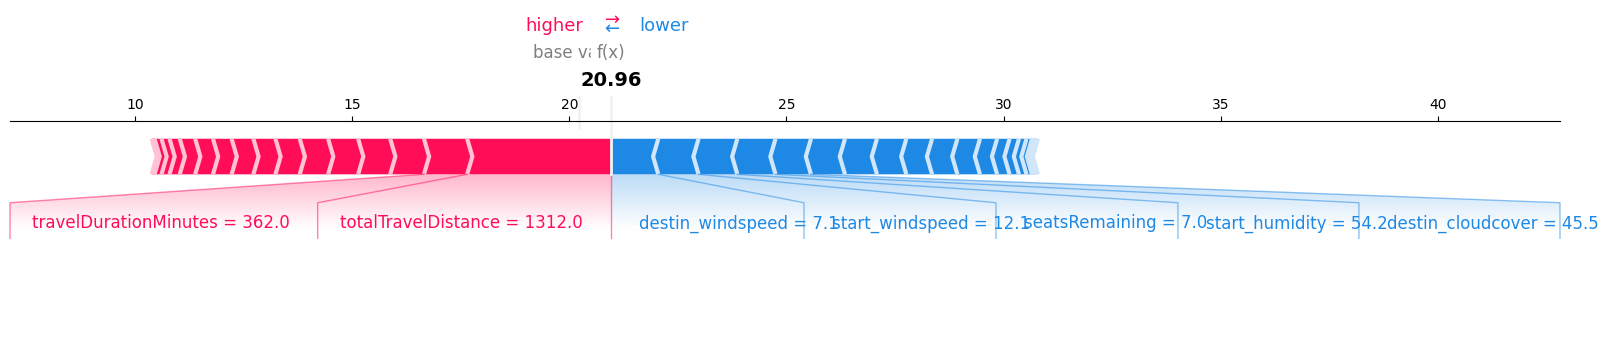

In [95]:
import shap
import lightgbm as lgb
import matplotlib.pyplot as plt

# SHAP explainer 생성
explainer = shap.TreeExplainer(model)

# 계산 시간 단축을 위해 1000개 샘플만 사용
X_sample = X_test.sample(1000, random_state=42)
shap_values = explainer.shap_values(X_sample)

# SHAP 요약 플롯
shap.summary_plot(shap_values, X_sample, feature_names=X.columns)

# SHAP Force Plot (개별 예측 설명)
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[0], X_sample.iloc[0], matplotlib=True)

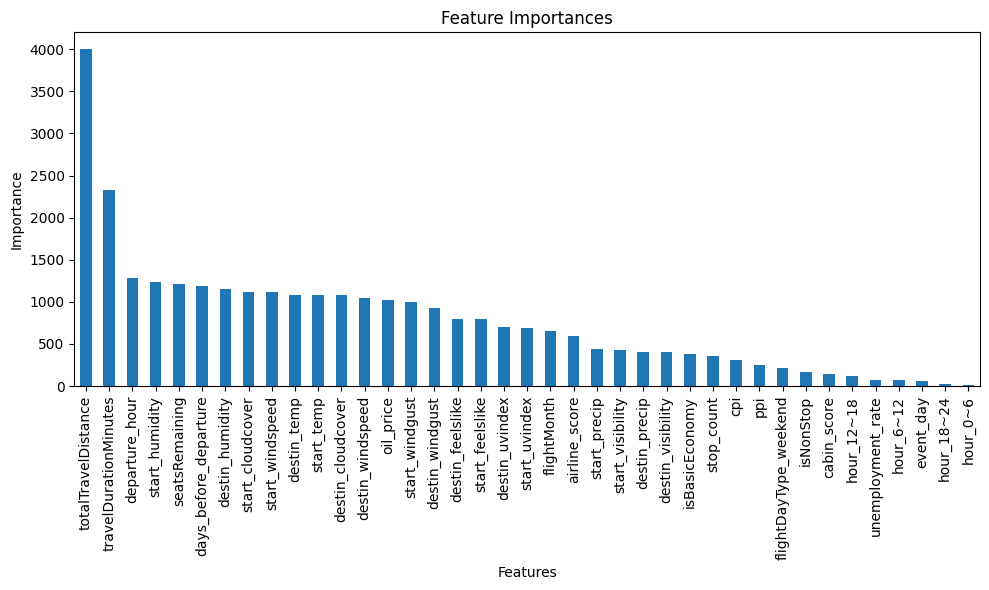

In [96]:
import matplotlib.pyplot as plt
import pandas as pd

# 1) Feature importance 배열 가져오기
importances = model.feature_importances_
features = X_train.columns  # 학습에 사용한 DataFrame의 컬럼명

# 2) Pandas Series로 변환해서 정렬
fi_series = pd.Series(importances, index=features).sort_values(ascending=False)

# 3) 막대그래프로 시각화
plt.figure(figsize=(10, 6))
fi_series.plot(kind="bar")
plt.title("Feature Importances")
plt.ylabel("Importance")
plt.xlabel("Features")
plt.tight_layout()
plt.show()


In [88]:
# 모델 저장
import joblib
joblib.dump(model, 'saved_lgb_model.pkl')

['saved_lgb_model.pkl']

Test 데이터: 제거 전 샘플 수 = 1068
            제거 후 샘플 수 = 1006
            제거된 샘플 수 = 62
Test: X 전체 shape = (Box-Cox 적용 후) = (1006, 39)

--Test 성능 (Box-Cox 스케일)────────────────────────
MSE:  7.1707
RMSE: 2.6778
R²:   0.7884
MAPE: 12.4856%

--Test 성능 (원본 스케일)────────────────────────
MSE           : 7619.02
R² Score      : 0.77
MAE           : 61.54
Median AE     : 44.52
MAPE (실제 %) : 30.49%


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
<ipython-input-100-e46ac05f9c2e>:152: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-100-e46ac05f9c2e>:152: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-100-e46ac05f9c2e>:152: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-100-e46ac05f9c2e>:152: UserWarning: Glyph 52992 (\N{HANGUL SYLLABLE KE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-100-e46ac05f9c2e>:152: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: G

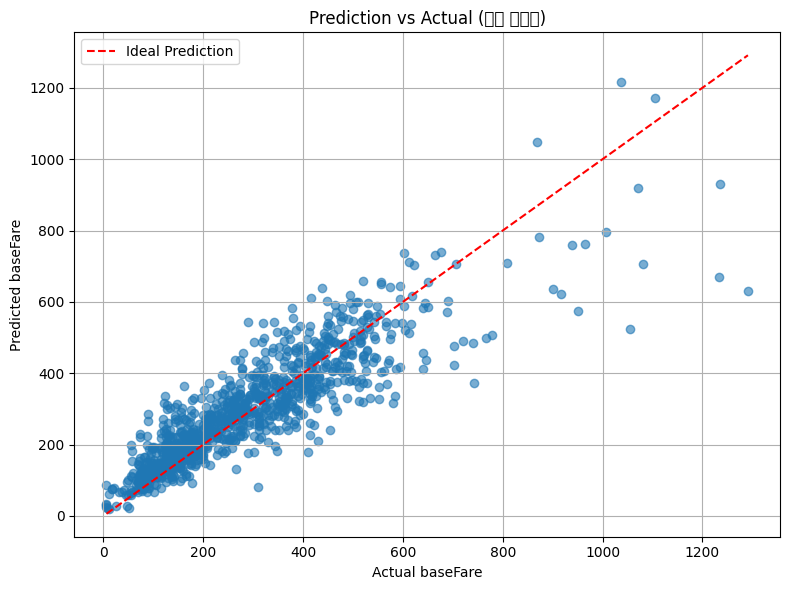

<ipython-input-100-e46ac05f9c2e>:163: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-100-e46ac05f9c2e>:163: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-100-e46ac05f9c2e>:163: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-100-e46ac05f9c2e>:163: UserWarning: Glyph 52992 (\N{HANGUL SYLLABLE KE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-100-e46ac05f9c2e>:163: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


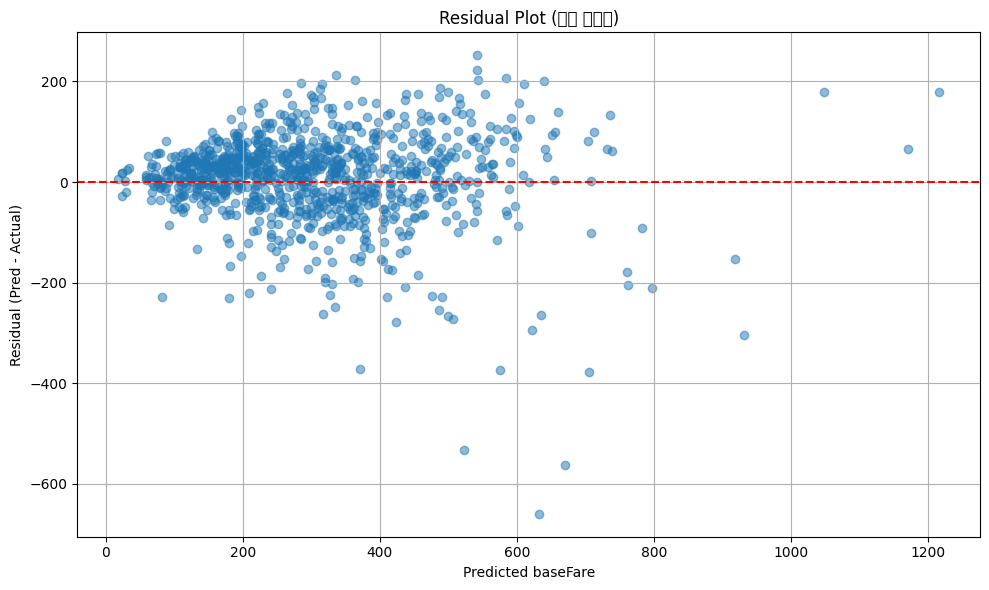

<ipython-input-100-e46ac05f9c2e>:172: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-100-e46ac05f9c2e>:172: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-100-e46ac05f9c2e>:172: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-100-e46ac05f9c2e>:172: UserWarning: Glyph 52992 (\N{HANGUL SYLLABLE KE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-100-e46ac05f9c2e>:172: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


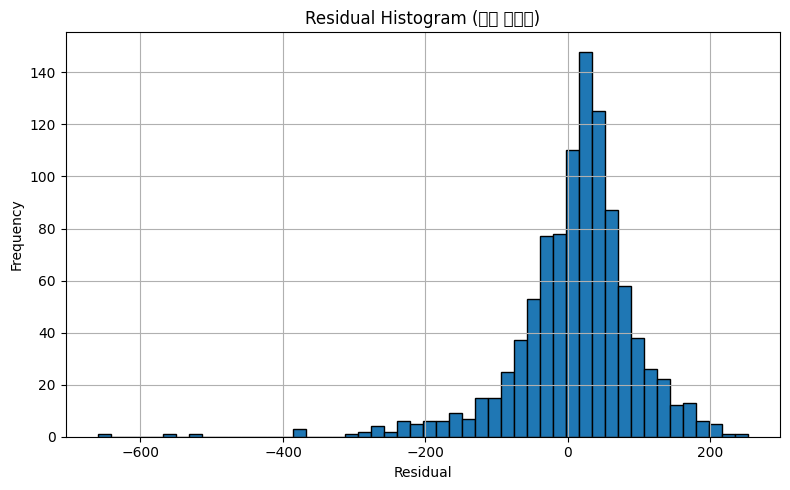

In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import boxcox
from scipy.special import inv_boxcox
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    mean_absolute_error,
    median_absolute_error,
    mean_absolute_percentage_error
)

# ──────────────────────────────────────────────────
# 1) Test 데이터 로드 & IQR 기반 이상치 제거
# ──────────────────────────────────────────────────
test_df = pd.read_csv("test_1000_final.csv")

continuous_cols = [
    'travelDurationMinutes',
    'start_humidity',
    'start_windgust',
    'start_windspeed',
    'destin_humidity',
    'destin_windgust',
    'destin_windspeed',
]

# (1) 섭씨 → 화씨 변환 (출발지)
test_df['start_temp']      = test_df['start_temp'] * 9/5 + 32
test_df['start_feelslike'] = test_df['start_feelslike'] * 9/5 + 32

# (1.1) 섭씨 → 화씨 변환 (도착지)
test_df['destin_temp']      = test_df['destin_temp'] * 9/5 + 32
test_df['destin_feelslike'] = test_df['destin_feelslike'] * 9/5 + 32

# (2) Test 데이터에서 IQR 계산
Q1_test  = test_df[continuous_cols].quantile(0.25)
Q3_test  = test_df[continuous_cols].quantile(0.75)
IQR_test = Q3_test - Q1_test

lower_test = Q1_test - 1.5 * IQR_test
upper_test = Q3_test + 1.5 * IQR_test

# (3) 이상치 마스크 생성 및 제거
mask_test = ~((test_df[continuous_cols] < lower_test) |
              (test_df[continuous_cols] > upper_test)).any(axis=1)
test_cleaned = test_df[mask_test].copy()

print(f"Test 데이터: 제거 전 샘플 수 = {len(test_df)}")
print(f"            제거 후 샘플 수 = {len(test_cleaned)}")
print(f"            제거된 샘플 수 = {len(test_df) - len(test_cleaned)}")

# ──────────────────────────────────────────────────
# 2) Box-Cox 변환 (baseFare > 0 필터링 & λ는 학습 때와 동일하게 재사용)
# ──────────────────────────────────────────────────
# (학습 코드에서 이미 구해 놓은 fitted_lambda를 메모리에서 사용한다고 가정)

test_box = test_cleaned[test_cleaned['baseFare'] > 0].copy()
test_box['boxcox_baseFare'] = boxcox(test_box['baseFare'], lmbda=fitted_lambda)

# ──────────────────────────────────────────────────
# 3) 피처 정리 (학습 때 drop했던 컬럼 제거)
# ──────────────────────────────────────────────────
drop_cols = [
    'baseFare',
    'boxcox_baseFare',
    'log_baseFare',
    'fare_per_minute',
    'via_count',
    'daysBeforeFlight'
]
existing_drop = [c for c in drop_cols if c in test_box.columns]
X_test = test_box.drop(columns=existing_drop)
y_test_box = test_box['boxcox_baseFare'].values

print("Test: X 전체 shape = (Box-Cox 적용 후) =", X_test.shape)

# ──────────────────────────────────────────────────
# 4) 컬럼 순서 재정렬 → 학습 때 X_train.columns 순서에 맞추기
# ──────────────────────────────────────────────────

# 여기서는 실제 학습 때의 컬럼 순서를 바로 가져와야 합니다.
# 만약 Colab 세션에서 학습 코드가 이미 실행된 상태라면 아래처럼 가능:
train_feature_columns = X_train.columns.tolist()

# → 테스트셋 X_test를 동일한 순서대로 재정렬
X_test = X_test[train_feature_columns]

# ──────────────────────────────────────────────────
# 5) 스케일링 (학습 때 사용한 scaler를 메모리에서 재사용)
# ──────────────────────────────────────────────────

X_test_scaled = scaler.transform(X_test)

# ──────────────────────────────────────────────────
# 6) 모델 예측 (학습 때 fit된 model을 메모리에서 재사용)
# ──────────────────────────────────────────────────
# 여기서는 이미 메모리에 있는 model 변수를 사용

y_pred_box = model.predict(X_test_scaled, num_iteration=model.best_iteration_)

# ──────────────────────────────────────────────────
# 7) Box-Cox 스케일에서 평가 지표
# ──────────────────────────────────────────────────
mse_box  = mean_squared_error(y_test_box, y_pred_box)
rmse_box = np.sqrt(mse_box)
r2_box   = r2_score(y_test_box, y_pred_box)
mape_box = mean_absolute_percentage_error(y_test_box, y_pred_box)

print(f"\n--Test 성능 (Box-Cox 스케일)────────────────────────")
print(f"MSE:  {mse_box:.4f}")
print(f"RMSE: {rmse_box:.4f}")
print(f"R²:   {r2_box:.4f}")
print(f"MAPE: {mape_box * 100:.4f}%")

# ──────────────────────────────────────────────────
# 8) 원본 스케일(baseFare)으로 역변환 & 평가
# ──────────────────────────────────────────────────
y_pred_orig = inv_boxcox(y_pred_box, fitted_lambda)
# test_box에는 이미 학습 때와 동일한 순서로 필터링된 데이터가 들어 있으므로
# 인덱스 매칭 없이 바로 values로 비교 가능
y_true_orig = test_box['baseFare'].values

mse_orig   = mean_squared_error(y_true_orig, y_pred_orig)
r2_orig    = r2_score(y_true_orig, y_pred_orig)
mae_orig   = mean_absolute_error(y_true_orig, y_pred_orig)
medae_orig = median_absolute_error(y_true_orig, y_pred_orig)
mape_orig  = mean_absolute_percentage_error(y_true_orig, y_pred_orig)

print(f"\n--Test 성능 (원본 스케일)────────────────────────")
print(f"MSE           : {mse_orig:.2f}")
print(f"R² Score      : {r2_orig:.2f}")
print(f"MAE           : {mae_orig:.2f}")
print(f"Median AE     : {medae_orig:.2f}")
print(f"MAPE (실제 %) : {mape_orig * 100:.2f}%")

# ──────────────────────────────────────────────────
# 9) 예측 vs 실제 시각화 (원본 스케일)
# ──────────────────────────────────────────────────
plt.figure(figsize=(8, 6))
plt.scatter(y_true_orig, y_pred_orig, alpha=0.6)
plt.plot([y_true_orig.min(), y_true_orig.max()],
         [y_true_orig.min(), y_true_orig.max()],
         '--r', label='Ideal Prediction')
plt.xlabel('Actual baseFare')
plt.ylabel('Predicted baseFare')
plt.title('Prediction vs Actual (원본 스케일)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

resid = y_pred_orig - y_true_orig
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_orig, resid, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted baseFare')
plt.ylabel('Residual (Pred - Actual)')
plt.title('Residual Plot (원본 스케일)')
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(resid, bins=50, edgecolor='black')
plt.title('Residual Histogram (원본 스케일)')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()
